# Simple Neural Network | MNIST

Implmentation of a configurable nerual network and trained on the MNIST digit classifer dataset. 
To test my understanding, only basic data and math libraries will be used.

### Packages and Dataset

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

train_data = pd.read_csv('../mnist/mnist_train.csv', header=None)
test_data = pd.read_csv('../mnist/mnist_test.csv', header=None)

The MNIST data set is in csv, with each row being one entry, 784 columns for each pixle on a 28 x 28 grid, the value representing brightness value from 0 to 1 black to white. 

In [2]:
# first column of the data is the digit
def parse_data(df):
    X = np.array(df.iloc[:,1:])
    Y = np.array(df.iloc[:,0])
    return X, Y

parse and load training and testing data and verfying shape

In [3]:
X, Y = parse_data(train_data)
X_te, Y_te = parse_data(test_data)
# normalize X
X = X / 255.0
X_te = X_te / 255.0

m,p = X.shape
X.shape

(60000, 784)

### Visualize Data Entries

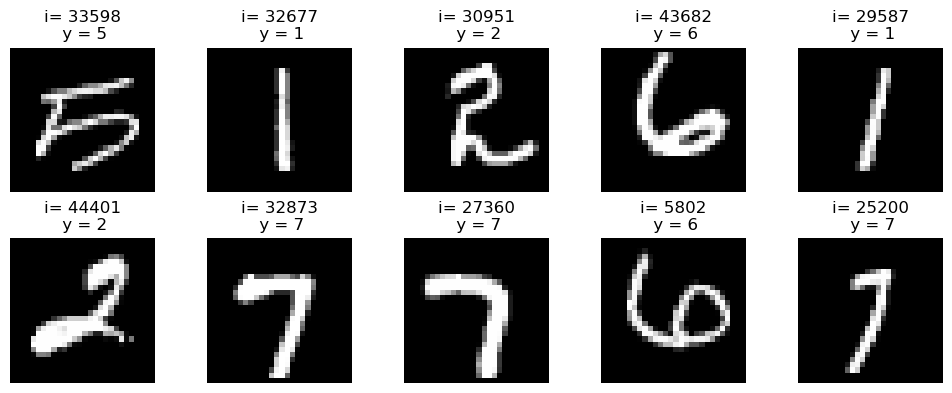

In [4]:
def plot_mnist(idxs, X_data, Y_data, rows):
    p_w, p_h = 2,2
    
    m = int(rows)
    n = int(len(idxs)/rows)
    fig, axes = plt.subplots(m, n, figsize=(p_w*n, p_h*m))
    for i, ax in enumerate(axes.flat):   
        ax.imshow(X_data[idxs[i],].reshape(28,28),cmap='gray', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"i= {idxs[i]}\n y = {Y_data[idxs[i]]}" )
    plt.tight_layout()
    plt.show()

plot_mnist(np.random.default_rng().integers(size=10, low=0, high=m-1), X, Y, 2)

# Model Formulation
Each observation in the dataset is of dimension $28 \times 28$. The simplest representation of how we want to pass this data to the model would be to align all pixle values in one long vector of size $784$.
$$
X = (X_1, X_2, \cdots, X_m)^T , \hspace{.5cm}X_i\in \mathbb{R}^{1\times784}
$$

<small>we can also introduce more complicated 2-d relations to the model before passing it to the network, making it a CNN</small>

The prediction of our model should be a function conditioned on our training data $\hat{Y}_{tr} = f(X_{tr})$, which can be used to predict our test data $\hat{Y}_{te} = f(X_{te})$ to evaulate performance.

Since we are classifing the digits, their numerical values are meaningless. First we one-hot encode our target classes to 
$$
Y_i = (y_0, y_1, \cdots, y_9) ,\hspace{.5cm} \text{where only} \hspace{.5cm} y_j = 1 \text{ if } Y_i \in j \text{ class}
$$
We have several choices of criterions that can evaluate our model, but we will use Cross Entropy for the multi-class loss function,
$$
L(Y;\hat{Y}) = - \frac{1}{m} \sum_{i=1}^m \sum_{j=1}^{10} y_{ij} \log (\hat{y}_{ij})
$$
The objective of fitting the model will be to minimize $L$ in respect to our parameters given $X$.

For this specific implmentation, we will implment 2 hidden layers, with 256 and 128 nodes respectively. I will generalize this formulation later.

![Neural Network diagram from ISPL pg 404](./nn_layers.png)

# Notations
|Layer| Quantity | Definition | Size |
|:---:| :---: | :--- | :---: |
|**Input**||||
||$X = A^{[0]}$|Input| $m \times 784$|
|**Layer 1**||||
||$W^{[1]}$|Layer $1$ Weight | $784 \times 256$|
||$b^{[1]}$|Layer $1$ Bias |$1 \times 256$|
||$Z^{[1]}$|Layer $1$ Pre-activation| $m\times256$|
||$A^{[1]}$|Layer $1$ Activation| $m\times256$|
|**Layer 2**||||
||$W^{[2]}$|Layer $2$ Weight | $256 \times 128$|
||$b^{[2]}$|Layer $2$ Bias |$1 \times 128$|
||$Z^{[2]}$|Layer $2$ Pre-activation| $m\times128$|
||$A^{[2]}$|Layer $2$ Activation| $m\times128$|
|**Output Layer**||||
||$W^{[3]}$|Output Weight | $128 \times 10$|
||$b^{[3]}$|Output Bias |$1 \times 10$|
||$Z^{[3]}$|Output Logits| $m\times10$|
||$\hat{Y}$|Predicted Probabilities| $m\times10$|
||$Y$|Target| $m\times10$|

# Forward Propagation

Before we fit the model, we need to pass data, either a batch or then entire training set, through the model to get our predictions. This forward pass depends on our model architecture and will affect how the backward pass during the fitting of the model.   

Starting with the simple linear componet
$$
Z^{[1]} = XW^{[1]} + b^{[1]},
$$
where $W^{[l]}, b^{[l]}$ are matrcies of trainable parameters.

To capture non-linear interactions between nodes, we need to define a non-linear activation function 
$$
g(z) := \text{ReLU}(z) = \begin{cases} 0 & \text{ if } z<0, \\
z & \text{ if } z \geq 0
\end{cases}
$$
allowing us to capture higher dimension patterns if we apply this on the result of the linear componet
$$
A^{[1]} = g(Z^{[1]}).
$$
We repeat this for the next two layers, taking the output of the previous layer as input for the next,
$$Z^{[2]} = A^{[1]}W^{[2]} + b^{[2]}$$
$$A^{[2]} = g(Z^{[2]})$$
$$Z^{[3]} = A^{[2]}W^{[3]} + b^{[3]}.$$
But, before we activate the output of our last layer, instead we need to return a probability distribution of our results. Therefore we will apply the softmax function 
$$
\text{softmax}(z_j) = \frac{e^{z_j}}{\sum_{r=1}^{k}e^{z_r}} \text{ for $j$th class in $k$ total class.}
$$
element wise to the output of our 3rd linear layer to get our class prediction
$$
\hat{Y} = \text{softmax}(Z^{[3]}) \hspace{.5cm} \text{where }\hat{y}_{ij} = \frac{e^{z_{ij}}}{\sum_{r=1}^{k}e^{z_{ir}}}.
$$

In [5]:
def init_params(layers):
    # layers be array of layer sizes, including all input, nodes, and output size
    W = []
    b = []
    
        # He Kaiming initialization, optimial for ReLU activation 
        # to preserve variance during forward and backward pass
    for l in range(len(layers)-1):
        W.append(np.random.normal(
                loc=0, 
                scale=np.sqrt(2 / layers[l]),
                size=(layers[l], layers[l+1])))
        b.append(np.zeros((1, layers[l+1])))

    return W, b
    return (W,b)


In [6]:
def relu(Z):
    #elementwise relu for vector Z
    return np.maximum(0,Z)

def softmax(Z):
    #elementwise softmax for vector Z
    #exp can be instable, but it is shift invariant
    #we can set max exp(Z) to 1 by subtracting by max(z) in exp
    Z_shift = Z - np.max(Z, axis=1, keepdims=True)
    exp_Z = np.exp(Z_shift)
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

In [7]:
def forward_prop(X, param):
    W, b = param
    # X = A[0]
    A = [X]    
    Z = []
    for l in range(len(b)-1):
        Z.append(A[l].dot(W[l]) + b[l])
        A.append(relu(Z[l]))   
    Z.append(A[-1].dot(W[-1]) + b[-1])
    #A[-1] = Y_hat
    A.append(softmax(Z[-1]))
    return(Z, A[:-1], A[-1])

In [8]:
# following our set layer structure
layers = [784, 256, 128, 10]
param = init_params(layers)
# one simple forward pass with our entire training set as one batch
Z, A, Y_hat = forward_prop(X, param)

# Back Propagation

After passing our training data through the network, we have a prediction $\hat{Y}$ for each observation. We can now compare these predictions against our target $Y$ using the cross entropy loss.

In [9]:
def cross_entropy(Y, Y_hat):
    #entropy of each observation
    return -1 * Y * np.log(Y_hat)

To fit the model while minimizing $L$, it is helpful to know how adjusting each parameter will change our loss. Taking the gradient of the loss with respect to all trainable parameters will give us the direction to change our parameter that increases our loss, and which we will take a ratio of the negative of that direction to update our parameters. 

Viewing $L$ as a function of $W$ and $b$, and taking the gradient in respect to each would require applying the chain rule across each layer to get the respective derivative of each quantity
$$
\nabla{L} = \left[ \frac{\partial L}{\partial W^{[3]}}, \frac{\partial L}{\partial b^{[3]}}, \frac{\partial L}{\partial W^{[2]}}, \frac{\partial L}{\partial b^{[2]}}, \frac{\partial L}{\partial W^{[1]}}, \frac{\partial L}{\partial b^{[1]}},\right].
$$
Deriving each quantity via the chain rule, for layer $l$,
$$
\frac{\partial L}{\partial W^{[l]}} = \frac{\partial Z^{[l]}}{\partial W^{[l]}} \frac{\partial A^{[l]}}{\partial Z^{[l]}} \frac{\partial L}{\partial A^{[l]}} \hspace{.5cm} \text{ and } \hspace{.5cm} \frac{\partial L}{\partial b^{[l]}} = \frac{\partial Z^{[l]}}{\partial b^{[l]}} \frac{\partial A^{[l]}}{\partial Z^{[l]}} \frac{\partial L}{\partial A^{[l]}}.
$$
It is useful to keep the intermediate quantity
$$
\delta^{[l]} := \frac{\partial L}{\partial Z^{[l]}} = \frac{\partial A^{[l]}}{\partial Z^{[l]}} \frac{\partial L}{\partial A^{[l]}}.
$$

Starting from the output, which uses the softmax function, and our loss function is the average multi-class cross entropy. Both combined with one-hot encoding, we can simplfy the derivative of the loss in respect to logits to
$$
\delta^{[3]}:= \frac{\partial L}{\partial Z^{[3]}}= \frac{1}{m} \left(\hat{Y}-Y\right) \in\mathbb{R}^{m\times10}.
$$

Continuing to our linear weights of the third layer, we have
$$
\frac{\partial L}{\partial W^{[3]}} = \frac{\partial Z^{[3]}}{\partial W^{[3]}} \frac{\partial A^{[3]}}{\partial Z^{[3]}} \frac{\partial L}{\partial A^{[3]}} = \frac{\partial Z^{[3]}}{\partial W^{[3]}} \delta^{[3]} = (A^{[2]})^T \delta^{[3]} \in \mathbb{R}^{128 \times 10},
$$
$$
\frac{\partial L}{\partial b^{[3]}} = \frac{\partial Z^{[3]}}{\partial b^{[3]}} \delta^{[3]} = \mathbf{1}^T \delta^{[3]} = \sum_{i=1}^m \delta^{[3]}_i \in \mathbb{R}^{1 \times 10}
$$
Before backpropagating into layer 2, we need
$$
\delta^{[2]} = \frac{\partial L}{\partial Z^{[2]}} = \frac{\partial A^{[2]}}{\partial Z^{[2]}} \frac{\partial L}{\partial A^{[2]}}.
$$
Individually we get
$$
\frac{\partial A^{[2]}}{\partial Z^{[2]}} = \text{ReLU}'(Z^{[2]}) = \begin{cases} 1 & \text{ if } z > 0, \\ 0 & \text{ if }  z < 0. \end{cases}
$$
$$
\frac{\partial L}{\partial A^{[2]}} = \frac{\partial L}{\partial Z^{[3]}} \frac{\partial Z^{[3]}}{\partial A^{[2]}} = \delta^{[3]}(W^{[3]})^T
$$
and elementwise multiply them together we get
$$
\delta^{[2]} = \delta^{[3]}(W^{[3]})^T \odot \text{ReLU}'(Z^{[2]}) \in \mathbb{R}^{m \times 128}.
$$

Continue the linear and activation steps above to get the rest of the gradient:
$$
\frac{\partial L}{\partial W^{[2]}} = (A^{[1]})^T \delta^{[2]} \in \mathbb{R}^{256 \times 128}
$$
$$
\frac{\partial L}{\partial b^{[2]}} = \mathbf{1}^T \delta^{[2]} \in \mathbb{R}^{1 \times 128}
$$
$$
\delta^{[1]} = \delta^{[2]}(W^{[2]})^T \odot \text{ReLU}'(Z^{[1]}) \in \mathbb{R}^{m \times 256}
$$
$$
\frac{\partial L}{\partial W^{[1]}} = (A^{[0]})^T \delta^{[1]} \in \mathbb{R}^{m \times 256}
$$
$$
\frac{\partial L}{\partial b^{[1]}} = \mathbf{1}^T \delta^{[1]} \in \mathbb{R}^{1 \times 256}
$$

In [10]:
def relu_d(z):
    return (z>0)

def back_prop(param, Z, A, Y_hat, Y):
    #one hot encode our original Y variable
    W, b = param
    Y = np.eye(W[-1].shape[1])[Y]
    
    #we don't necessarily need to call cross entropy
    #derivative of our softmax combined with cross entropy simplfies to
    dZ3 = 1/m * (Y_hat - Y)
    
    dW3 = A[2].T.dot(dZ3)
    db3 = np.sum(dZ3, axis=0, keepdims=True)
    
    dZ2 = dZ3.dot(W[2].T) * relu_d(Z[1])
    dW2 = A[1].T.dot(dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dZ1 = dZ2.dot(W[1].T) * relu_d(Z[0])
    dW1 = A[0].T.dot(dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return [dW1, dW2, dW3], [db1, db2, db3] 


Using $\nabla{L}$, we can update the respective parameters in the negative direction of the gradient to minimize $L$
$$
\Theta_{\text{new}} = \Theta_{\text{old}} - \alpha \nabla{L} 
$$
with the learning rate $\alpha$ being a hyperparameter to slow down parameter update, helping with better convergence.

In [11]:
def update_params(param, dparam, alpha):
    W, b = param
    dW, db = dparam
    for i in range(len(W)):
        W[i] = W[i] - alpha * dW[i]
        b[i] = b[i] - alpha * db[i]
    return (W,b)

In [12]:
def acc(Y, Y_hat):
    return np.mean(np.argmax(Y_hat, axis=1) == Y)

# Gradient Descent
Since each forward and backward pass will only increment our loss by a certain amount, and finding the global minimum is usually not possible in higher dimensional loss landscapes like this, we will iteratively apply our forward and backward propagation to fit our model.

In [13]:
layers = [784, 256, 128, 10]
def gradient_descent(X,Y, epoch, alpha):
    param = init_params(layers)
    for i in range(epoch):
        Z, A, Y_hat = forward_prop(X, param)
        dparam = back_prop(param, Z, A, Y_hat, Y)
        param = update_params(param, dparam, alpha)
        if i % 5 == 0:
            print(f"epoch: {i} \t acc : {np.round(acc(Y,Y_hat),5)} \t loss: {np.round(np.mean(cross_entropy(np.eye(10)[Y],Y_hat)),5)}")        
    return param

In [14]:
print("traing")
param = gradient_descent(X,Y,50, .1)
_, _, Y_pred = forward_prop(X_te, param)
print(f"\ntest acc: {acc(Y_te,Y_pred)}")

traing
epoch: 0 	 acc : 0.08248 	 loss: 0.24913
epoch: 5 	 acc : 0.49587 	 loss: 0.19059
epoch: 10 	 acc : 0.67982 	 loss: 0.1502
epoch: 15 	 acc : 0.75508 	 loss: 0.11724
epoch: 20 	 acc : 0.7966 	 loss: 0.09463
epoch: 25 	 acc : 0.8219 	 loss: 0.07982
epoch: 30 	 acc : 0.83837 	 loss: 0.06985
epoch: 35 	 acc : 0.85047 	 loss: 0.06284
epoch: 40 	 acc : 0.8592 	 loss: 0.05767
epoch: 45 	 acc : 0.86633 	 loss: 0.05371

test acc: 0.8805


In [20]:
def plot_pred(idxs, X_data, Y_data, rows, param):   
    p_w, p_h = 2,2
    
    m = int(rows)
    n = int(len(idxs)/rows)
    fig, axes = plt.subplots(m, n, figsize=(p_w*n, p_h*m))
    for i, ax in enumerate(axes.flat):
        _, _, pred = forward_prop(X_data[i,:], param)
        prediction = np.argmax(pred, axis=1)[0]
        
        ax.imshow(X_data[idxs[i],].reshape(28,28),cmap='gray', interpolation='nearest')
        ax.axis('off')
        ax.set_title(f"i= {idxs[i]}\n y = {Y_data[idxs][i]} \n prediction = {prediction}")
         
    plt.tight_layout()
    plt.show()

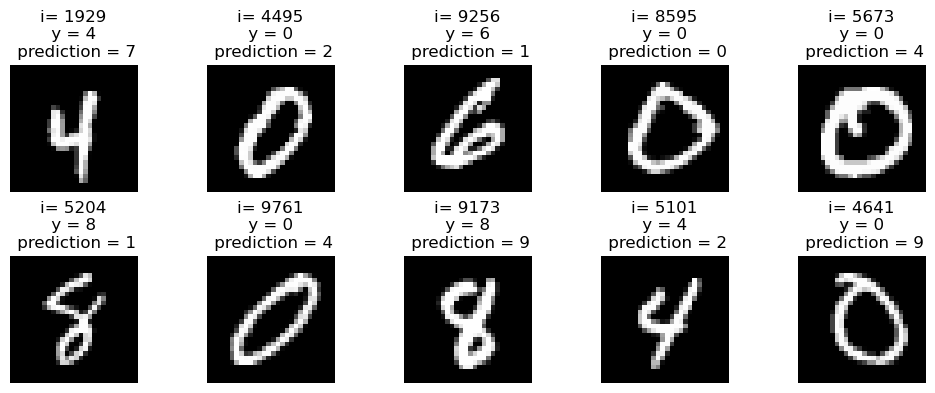

In [22]:
plot_pred(np.random.default_rng().integers(size=10, low=0, high=Y_te.size-1), X_te, Y_te, 2, param)